<a href="https://colab.research.google.com/github/amit20kr/coalrock-classifier/blob/main/coalrock_training_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# CELL 1 — DRIVE MOUNT, IMPORTS & VERIFIED DATA LOADING

import os, time, pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from google.colab import drive

drive.mount('/content/drive')

# VERSION CHECK
print(f"PyTorch : {torch.__version__}   ← pin this in backend/requirements.txt")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")

# PATHS
PROJECT_ROOT   = "/content/drive/MyDrive/coalrock_project2"
PROCESSED_PATH = os.path.join(PROJECT_ROOT, "processed_data")
MODELS_PATH    = os.path.join(PROJECT_ROOT, "models")
RESULTS_PATH   = os.path.join(PROJECT_ROOT, "results")
MODEL_SAVE_PATH = os.path.join(MODELS_PATH, "pcvit_expert.pth")

for d in [MODELS_PATH, RESULTS_PATH]:
    os.makedirs(d, exist_ok=True)

# LOAD TENSORS FROM PREPROCESSING NOTEBOOK
print("\nLoading verified tensors...")

X_train = np.load(os.path.join(PROCESSED_PATH, 'X_train.npy'))
y_train = np.load(os.path.join(PROCESSED_PATH, 'y_train.npy'))
X_val   = np.load(os.path.join(PROCESSED_PATH, 'X_val.npy'))
y_val   = np.load(os.path.join(PROCESSED_PATH, 'y_val.npy'))
X_test  = np.load(os.path.join(PROCESSED_PATH, 'X_test.npy'))
y_test  = np.load(os.path.join(PROCESSED_PATH, 'y_test.npy'))

# LABEL ENCODER
with open(os.path.join(PROCESSED_PATH, 'label_encoder.pkl'), 'rb') as f:
    le = pickle.load(f)

NUM_CLASSES = len(le.classes_)
CLASS_NAMES = [str(c) for c in le.classes_]

# SHAPE ASSERTIONS
assert X_train.shape[1:] == (3, 1500), f"Train shape wrong: {X_train.shape}"
assert X_val.shape[1:]   == (3, 1500), f"Val shape wrong: {X_val.shape}"
assert X_test.shape[1:]  == (3, 1500), f"Test shape wrong: {X_test.shape}"
assert NUM_CLASSES == 24, f"Expected 24 classes, got {NUM_CLASSES}"

print(f"X_train : {X_train.shape}  y_train: {y_train.shape}")
print(f"X_val   : {X_val.shape}    y_val:   {y_val.shape}")
print(f"X_test  : {X_test.shape}   y_test:  {y_test.shape}")
print(f"Classes : {NUM_CLASSES}")
print("\n Data loaded and verified.")


Mounted at /content/drive
PyTorch : 2.11.0+cu128   ← pin this in backend/requirements.txt
CUDA    : True
GPU     : Tesla T4

Loading verified tensors...
X_train : (7353, 3, 1500)  y_train: (7353,)
X_val   : (1578, 3, 1500)    y_val:   (1578,)
X_test  : (1566, 3, 1500)   y_test:  (1566,)
Classes : 24

 Data loaded and verified.


In [2]:
# CELL 2 — PCViT ARCHITECTURE

class PCViT(nn.Module):
    def __init__(self, num_classes=24):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv1d(3,   64,  kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Conv1d(64,  128, kernel_size=1, stride=1, padding=0),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Conv1d(128, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(128),
            nn.GELU(),
        )

        self.cls = nn.Parameter(torch.randn(1, 1, 128))
        self.pos = nn.Parameter(torch.randn(1, 376, 128))
        self.tf = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=128, nhead=4, dim_feedforward=512,
                dropout=0.1, activation='gelu', batch_first=True
            ),
            num_layers=4
        )

        self.head = nn.Sequential(
            nn.LayerNorm(128),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        assert x.shape[2] == 1500, (
            f"Band count {x.shape[2]} ≠ 1500. "
            "Check pipeline.py uses front-crop [:, :1500] not tail-crop."
        )
        x = self.stem(x)                                  # (B, 128, 375)
        x = x.permute(0, 2, 1)                           # (B, 375, 128)

        cls = self.cls.expand(x.shape[0], -1, -1)        # (B, 1, 128)
        x   = torch.cat([cls, x], dim=1)                 # (B, 376, 128)
        x   = x + self.pos[:, :x.shape[1], :]

        x = self.tf(x)                                    # (B, 376, 128)
        return self.head(x[:, 0, :])                      # (B, 24)


# XAVIER INITIALIZATION
def xavier_init(model):
    for m in model.modules():
        if isinstance(m, (nn.Conv1d, nn.Linear)):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.BatchNorm1d):
            nn.init.ones_(m.weight)
            nn.init.zeros_(m.bias)


# ARCHITECTURE SANITY CHECK
_m    = PCViT(num_classes=24)
_out  = _m(torch.randn(2, 3, 1500))
_p    = sum(p.numel() for p in _m.parameters())
assert _out.shape == (2, 24), f"Output shape wrong: {_out.shape}"
del _m, _out

print(f"Architecture verified.")
print(f"Parameters   : {_p:,}")
print(f"Stem channels: 3 → 64 → 128 → 128  (Conv1d kernel sizes: 3, 1, 3)")
print(f"Tokens       : 375 spectral + 1 CLS = 376")
print(f"Attribute keys for backend model.py: stem, cls, pos, tf, head")


Architecture verified.
Parameters   : 903,576
Stem channels: 3 → 64 → 128 → 128  (Conv1d kernel sizes: 3, 1, 3)
Tokens       : 375 spectral + 1 CLS = 376
Attribute keys for backend model.py: stem, cls, pos, tf, head


In [3]:
# CELL 3 — DEVICE-SAFE MIXUP

def mixup_data(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    index = torch.randperm(x.size(0), device=x.device)
    mixed_x = lam * x + (1 - lam) * x[index]
    return mixed_x, y, y[index], lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

print("MixUp functions defined.")
print("Phase 1 (epochs  0-29): alpha=0.2, MixUp ON")
print("Phase 2 (epochs 30-49): alpha=0.0, MixUp OFF (clean fine-tuning)")


MixUp functions defined.
Phase 1 (epochs  0-29): alpha=0.2, MixUp ON
Phase 2 (epochs 30-49): alpha=0.0, MixUp OFF (clean fine-tuning)


In [4]:
# CELL 4 — PYTORCH DATALOADERS
BATCH_SIZE = 128

train_ds = TensorDataset(
    torch.FloatTensor(X_train),
    torch.LongTensor(y_train)
)
val_ds = TensorDataset(torch.FloatTensor(X_val),  torch.LongTensor(y_val))
test_ds = TensorDataset(torch.FloatTensor(X_test), torch.LongTensor(y_test))

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    drop_last=True, num_workers=2, pin_memory=True, persistent_workers=True
)
val_loader  = DataLoader(
    val_ds,   batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    test_ds,  batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True
)

print(f"Batch size        : {BATCH_SIZE}")
print(f"Train batches/ep  : {len(train_loader)}")
print(f"Val   batches/ep  : {len(val_loader)}")


Batch size        : 128
Train batches/ep  : 57
Val   batches/ep  : 13


In [7]:
# CELL 5 — 2-STAGE TRAINING LOOP
import time

PHASE1_EPOCHS = 30
PHASE2_EPOCHS = 20
TOTAL_EPOCHS  = PHASE1_EPOCHS + PHASE2_EPOCHS

# DEVICE
device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
use_amp = (device.type == 'cuda')
print(f"Device : {device}  |  AMP : {use_amp}")

# MODEL
model = PCViT(num_classes=NUM_CLASSES).to(device)
xavier_init(model)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

# LOSS + OPTIMIZER
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=0.05
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=4
)

scaler = torch.amp.GradScaler('cuda', enabled=use_amp)

# HISTORY
history = {'train_loss': [], 'train_acc': [], 'val_acc': [], 'phase': []}
best_val_acc = 0.0
start_time   = time.time()

print(f"\nStarting {TOTAL_EPOCHS}-epoch 2-stage training...")
print(f"{'='*70}")

for epoch in range(TOTAL_EPOCHS):
    phase     = 1 if epoch < PHASE1_EPOCHS else 2
    use_mixup = (phase == 1)

    # ─ TRAINING
    model.train()
    running_loss  = 0.0
    train_correct = 0
    train_total   = 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        if use_mixup:
            inputs, y_a, y_b, lam = mixup_data(inputs, labels, alpha=0.2)
        else:
            y_a, y_b, lam = labels, labels, 1.0

        with torch.amp.autocast(device_type=device.type, enabled=use_amp):
            outputs = model(inputs)
            loss    = mixup_criterion(criterion, outputs, y_a, y_b, lam)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

        with torch.no_grad():
            _, preds = torch.max(outputs, 1)
            dominant = y_a if lam >= 0.5 else y_b
            train_correct += (preds == dominant).sum().item()
            train_total   += dominant.size(0)

    avg_loss  = running_loss / len(train_loader)
    train_acc = train_correct / train_total

    # ─ VALIDATION
    model.eval()
    val_correct = 0
    val_total   = 0

    with torch.no_grad():
        for v_inputs, v_labels in val_loader:
            v_inputs = v_inputs.to(device, non_blocking=True)
            v_labels = v_labels.to(device, non_blocking=True)
            with torch.amp.autocast(device_type=device.type, enabled=use_amp):
                v_outputs = model(v_inputs)
            _, v_preds = torch.max(v_outputs, 1)
            val_correct += (v_preds == v_labels).sum().item()
            val_total   += v_labels.size(0)

    val_acc = val_correct / val_total

    # ─ SCHEDULER (Phase 2 only)
    if phase == 2:
        scheduler.step(val_acc)

    # ─ CHECKPOINT
    saved = ""
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        saved = "  SAVED"

    # ─ HISTORY + LOG
    history['train_loss'].append(avg_loss)
    history['train_acc'].append(train_acc * 100)
    history['val_acc'].append(val_acc * 100)
    history['phase'].append(phase)

    current_lr = optimizer.param_groups[0]['lr']
    phase_tag = f"[P{phase} {'MixUp' if use_mixup else 'Clean'}]"

    print(
        f"Ep {epoch+1:>3}/{TOTAL_EPOCHS}  {phase_tag:<14} "
        f"LR: {current_lr:.1e}  "
        f"Loss: {avg_loss:.4f}  "
        f"Train: {train_acc*100:6.2f}%  "
        f"Val: {val_acc*100:6.2f}%"
        f"{saved}"
    )

elapsed = time.time() - start_time
print(f"\nTraining complete in {elapsed/60:.1f} min.")
print(f"Best val accuracy : {best_val_acc*100:.2f}%")

Device : cuda  |  AMP : True
Parameters: 903,576

Starting 50-epoch 2-stage training...
Ep   1/50  [P1 MixUp]     LR: 3.0e-04  Loss: 2.8553  Train:  13.29%  Val:  24.40%  SAVED
Ep   2/50  [P1 MixUp]     LR: 3.0e-04  Loss: 2.4209  Train:  25.23%  Val:  41.25%  SAVED
Ep   3/50  [P1 MixUp]     LR: 3.0e-04  Loss: 2.0524  Train:  38.34%  Val:  54.37%  SAVED
Ep   4/50  [P1 MixUp]     LR: 3.0e-04  Loss: 1.8356  Train:  46.22%  Val:  58.94%  SAVED
Ep   5/50  [P1 MixUp]     LR: 3.0e-04  Loss: 1.6085  Train:  53.30%  Val:  65.53%  SAVED
Ep   6/50  [P1 MixUp]     LR: 3.0e-04  Loss: 1.6154  Train:  57.04%  Val:  69.71%  SAVED
Ep   7/50  [P1 MixUp]     LR: 3.0e-04  Loss: 1.2909  Train:  63.39%  Val:  76.49%  SAVED
Ep   8/50  [P1 MixUp]     LR: 3.0e-04  Loss: 1.3033  Train:  66.04%  Val:  76.62%  SAVED
Ep   9/50  [P1 MixUp]     LR: 3.0e-04  Loss: 1.2411  Train:  68.24%  Val:  78.20%  SAVED
Ep  10/50  [P1 MixUp]     LR: 3.0e-04  Loss: 1.3319  Train:  67.06%  Val:  76.74%
Ep  11/50  [P1 MixUp]     LR:

In [8]:
model.load_state_dict(
    torch.load(MODEL_SAVE_PATH, map_location=device, weights_only=True)
)
model.eval()
print(f"Best checkpoint loaded. Val acc during training: {best_val_acc*100:.2f}%\n")

# TEST INFERENCE
y_true, y_pred = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device, non_blocking=True)
        with torch.amp.autocast(device_type=device.type, enabled=use_amp):
            outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
test_acc = (y_true == y_pred).mean() * 100

# CONSOLE REPORT
print(f"=== FINAL TEST SET RESULTS (unseen data) ===")
print(f"Overall accuracy : {test_acc:.2f}%")
print()
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

Best checkpoint loaded. Val acc during training: 96.77%

=== FINAL TEST SET RESULTS (unseen data) ===
Overall accuracy : 95.72%

                          precision    recall  f1-score   support

         0.3 coking coal       0.90      0.95      0.92        63
 Anthracite coal grade 1       0.98      0.87      0.92        62
 Anthracite coal grade 2       1.00      0.98      0.99        62
      Arenaceous shale 1       0.90      0.88      0.89        52
      Arenaceous shale 2       1.00      0.97      0.98        66
Argillaceous limestone 1       0.91      0.98      0.95        62
Argillaceous limestone 2       1.00      0.98      0.99        88
           Black shale 1       0.89      0.92      0.91        52
           Black shale 2       0.92      0.98      0.95        62
      Carbonaceous shale       0.97      1.00      0.98        62
                    Clay       0.98      0.98      0.98        88
             Coking coal       0.87      1.00      0.93        62
            

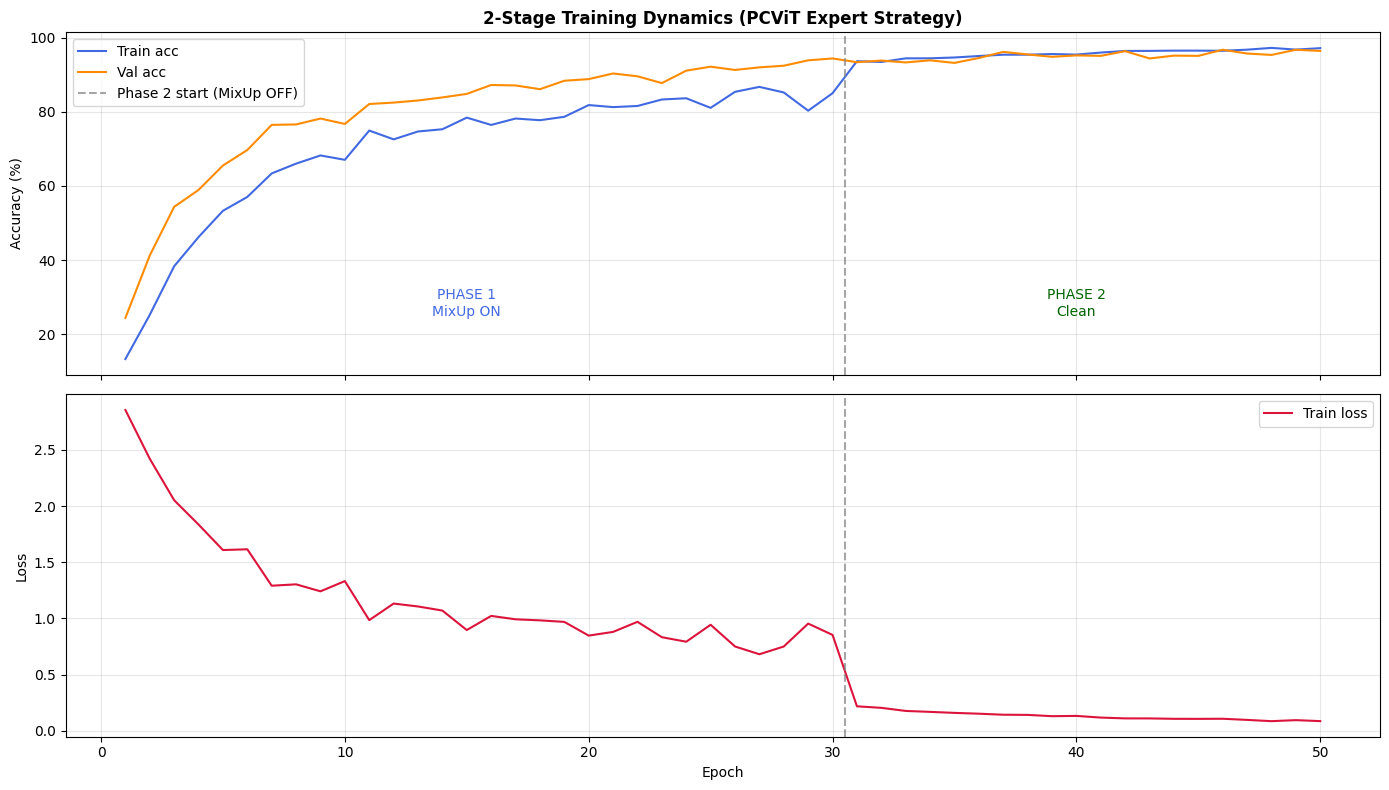

In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
epochs_x   = range(1, TOTAL_EPOCHS + 1)
p2_start   = PHASE1_EPOCHS + 0.5

ax1.plot(epochs_x, history['train_acc'], color='royalblue',  lw=1.5, label='Train acc')
ax1.plot(epochs_x, history['val_acc'],   color='darkorange', lw=1.5, label='Val acc')
ax1.axvline(p2_start, color='grey', ls='--', alpha=0.7, label='Phase 2 start (MixUp OFF)')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('2-Stage Training Dynamics (PCViT Expert Strategy)', fontweight='bold')
ax1.legend(); ax1.grid(True, alpha=0.3)
ax1.annotate('PHASE 1\nMixUp ON', xy=(PHASE1_EPOCHS*0.5, 25), ha='center', color='royalblue', fontsize=10)
ax1.annotate('PHASE 2\nClean', xy=(PHASE1_EPOCHS + PHASE2_EPOCHS*0.5, 25), ha='center', color='darkgreen', fontsize=10)

ax2.plot(epochs_x, history['train_loss'], color='crimson', lw=1.5, label='Train loss')
ax2.axvline(p2_start, color='grey', ls='--', alpha=0.7)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, 'training_curve.png'), dpi=200)
plt.show()

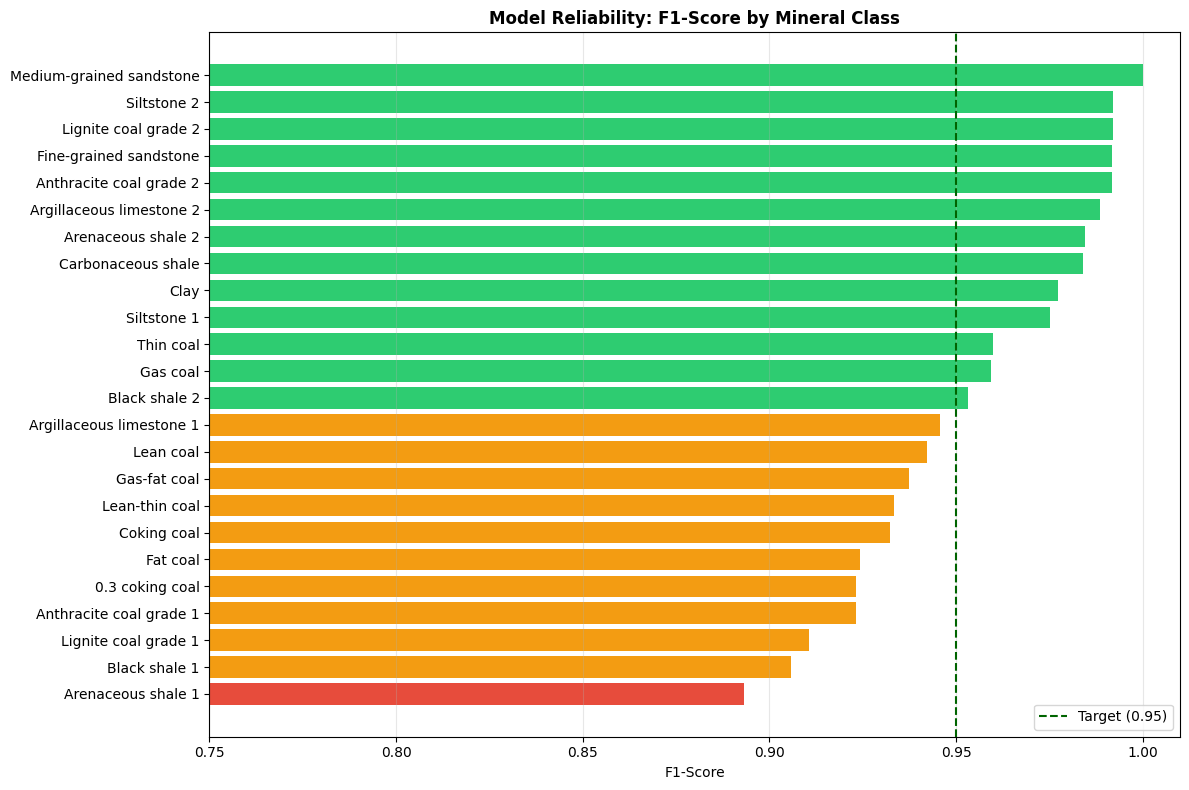

Weakest  : Arenaceous shale 1 — F1=0.8932
Strongest: Medium-grained sandstone — F1=1.0000
Mean F1  : 0.9550


In [10]:
f1_scores  = f1_score(y_true, y_pred, average=None)
sorted_idx = np.argsort(f1_scores)
colors     = ['#e74c3c' if s < 0.90 else '#f39c12' if s < 0.95 else '#2ecc71'
               for s in f1_scores[sorted_idx]]

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh([CLASS_NAMES[i] for i in sorted_idx], f1_scores[sorted_idx], color=colors)
ax.axvline(0.95, color='darkgreen', ls='--', lw=1.5, label='Target (0.95)')
ax.set_xlabel('F1-Score')
ax.set_title('Model Reliability: F1-Score by Mineral Class', fontweight='bold')
ax.set_xlim(0.75, 1.01); ax.legend(); ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, 'f1_scores.png'), dpi=200)
plt.show()

print(f"Weakest  : {CLASS_NAMES[np.argmin(f1_scores)]} — F1={np.min(f1_scores):.4f}")
print(f"Strongest: {CLASS_NAMES[np.argmax(f1_scores)]} — F1={np.max(f1_scores):.4f}")
print(f"Mean F1  : {f1_scores.mean():.4f}")

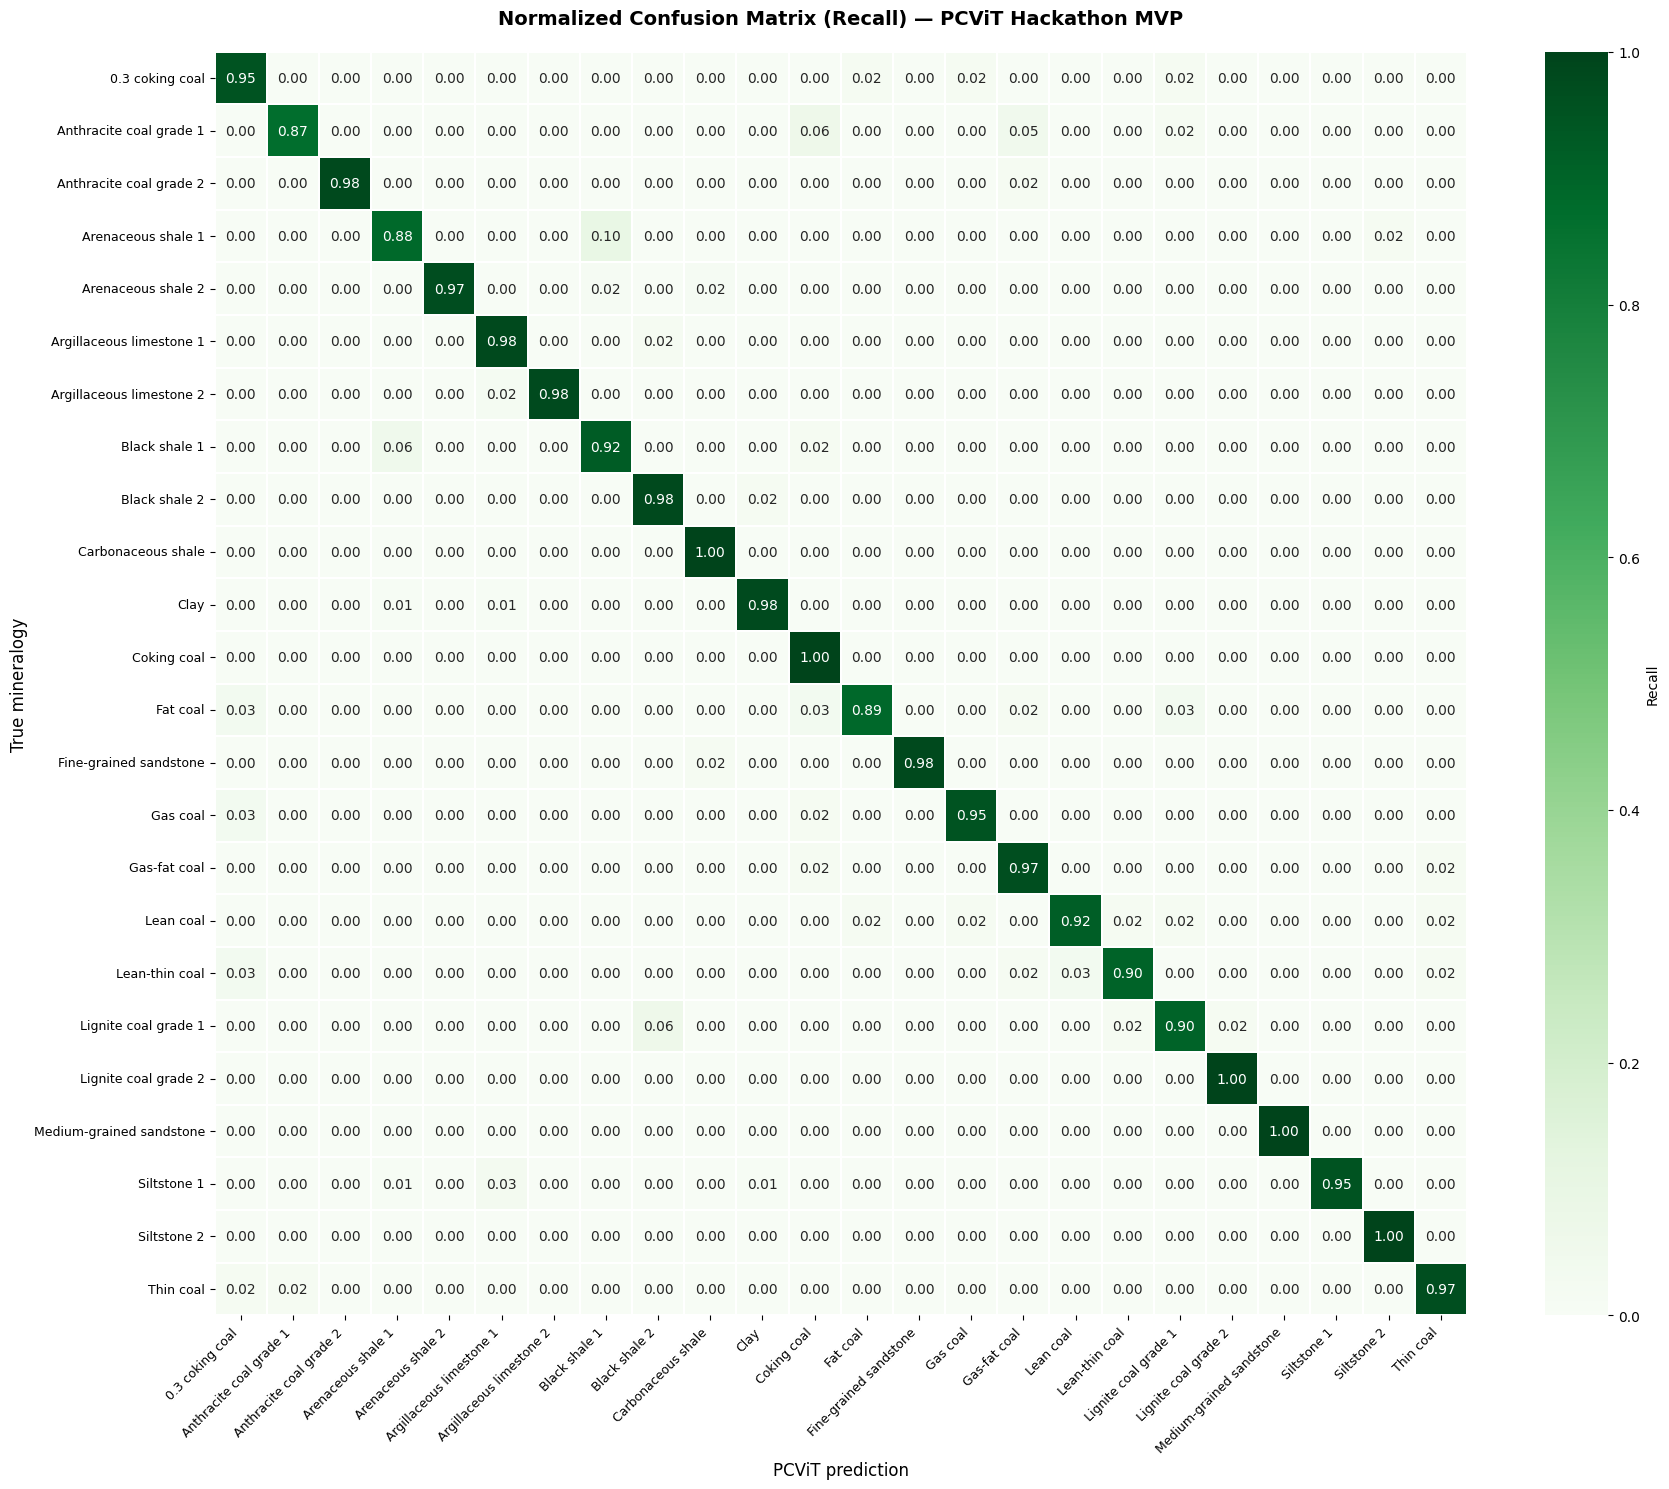

In [11]:
cm = confusion_matrix(y_true, y_pred, normalize='true')
plt.figure(figsize=(18, 15))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cbar_kws={'label': 'Recall'}, linewidths=0.3)
plt.title('Normalized Confusion Matrix (Recall) — PCViT Hackathon MVP',
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('True mineralogy', fontsize=12)
plt.xlabel('PCViT prediction', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, 'confusion_matrix.png'), dpi=300)
plt.show()

In [12]:
# FUEL-GANGUE BOUNDARY CHECK
FUEL_IDS   = {i for i, c in enumerate(CLASS_NAMES) if c in {
    'Anthracite coal grade 1', 'Anthracite coal grade 2',
    'Lean coal', 'Lean-thin coal', 'Thin coal', 'Coking coal', '0.3 coking coal',
    'Fat coal', 'Gas-fat coal', 'Gas coal', 'Lignite coal grade 1', 'Lignite coal grade 2'
}}
GANGUE_IDS = {i for i in range(NUM_CLASSES) if i not in FUEL_IDS}

violations = sum(
    1 for t, p in zip(y_true, y_pred)
    if t in GANGUE_IDS and p in FUEL_IDS
)
print(f"\nFuel-Gangue boundary violations: {violations} / {len(y_true)}")
if violations == 0:
    print("✅ Zero gangue misclassified as coal. Industrial safety criterion met.")
    print("   Demo line: 'Even across 1566 test spectra, the model NEVER let rock through as coal.'")
else:
    pct = violations / len(y_true) * 100
    print(f" {pct:.3f}% gangue entered coal prediction — check confusion matrix diagonal.")


Fuel-Gangue boundary violations: 1 / 1566
 0.064% gangue entered coal prediction — check confusion matrix diagonal.


In [14]:
# CELL 7 — ATOMIC SAVE VERIFICATION + DEPLOYMENT SUMMARY

print("Post-training verification...\n")

# VERIFY MODEL FILE FROM DISK (fresh CPU instance)
verify_model = PCViT(num_classes=NUM_CLASSES)   # CPU, no .to(device)
verify_model.load_state_dict(
    torch.load(MODEL_SAVE_PATH, map_location='cpu', weights_only=True)
)
verify_model.eval()
with torch.no_grad():
    dummy_out = verify_model(torch.randn(2, 3, 1500))

assert dummy_out.shape == (2, NUM_CLASSES), f"Output shape wrong: {dummy_out.shape}"
print(f"✅ pcvit_expert.pth loads on CPU correctly")
print(f"   Output shape : {dummy_out.shape}")

# RE-SAVE ENCODER FROM THIS SESSION
enc_path = os.path.join(MODELS_PATH, 'label_encoder.pkl')
with open(enc_path, 'wb') as f:
    pickle.dump(le, f)

# Reload and verify both copies match
with open(enc_path, 'rb') as f:
    le_check = pickle.load(f)
assert list(le_check.classes_) == list(le.classes_)
print(f" label_encoder.pkl re-saved and verified")
print(f"   Classes : {NUM_CLASSES}")

# DEPLOYMENT SUMMARY
model_mb = os.path.getsize(MODEL_SAVE_PATH) / 1e6
torch_ver = torch.__version__.split('+')[0]   # strip +cu121 suffix for requirements.txt

print(f"\n{'='*55}")
print(f"DEPLOYMENT PACKAGE READY")
print(f"  Model file  : pcvit_expert.pth  ({model_mb:.1f} MB)")
print(f"  Encoder     : models/label_encoder.pkl")
print(f"  Best val acc: {best_val_acc*100:.2f}%")
print(f"  Test acc    : {test_acc:.2f}%")
print(f"  Torch       : {torch.__version__}")
print(f"\nrequirements.txt pin:")
print(f"  torch=={torch_ver}")
print(f"\nBackend model.py attribute names:")
print(f"  stem, cls, pos, tf, head")


Post-training verification...

✅ pcvit_expert.pth loads on CPU correctly
   Output shape : torch.Size([2, 24])
 label_encoder.pkl re-saved and verified
   Classes : 24

DEPLOYMENT PACKAGE READY
  Model file  : pcvit_expert.pth  (3.6 MB)
  Encoder     : models/label_encoder.pkl
  Best val acc: 96.77%
  Test acc    : 95.72%
  Torch       : 2.11.0+cu128

requirements.txt pin:
  torch==2.11.0

Backend model.py attribute names:
  stem, cls, pos, tf, head


Binary Confusion (Fuel vs Gangue):
  TP (Coal→Coal)  :   741   Cost: $0
  FP (Coal→Rock)  :     4   Cost: $       400  (lost fuel)
  FN (Rock→Coal)  :     1   Cost: $    10,000  ← CRITICAL
  TN (Rock→Rock)  :   820   Cost: $0
  Total model damage   : $10,400
  Total random baseline: $7,830,000


/tmp/ipykernel_1914/1053045186.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


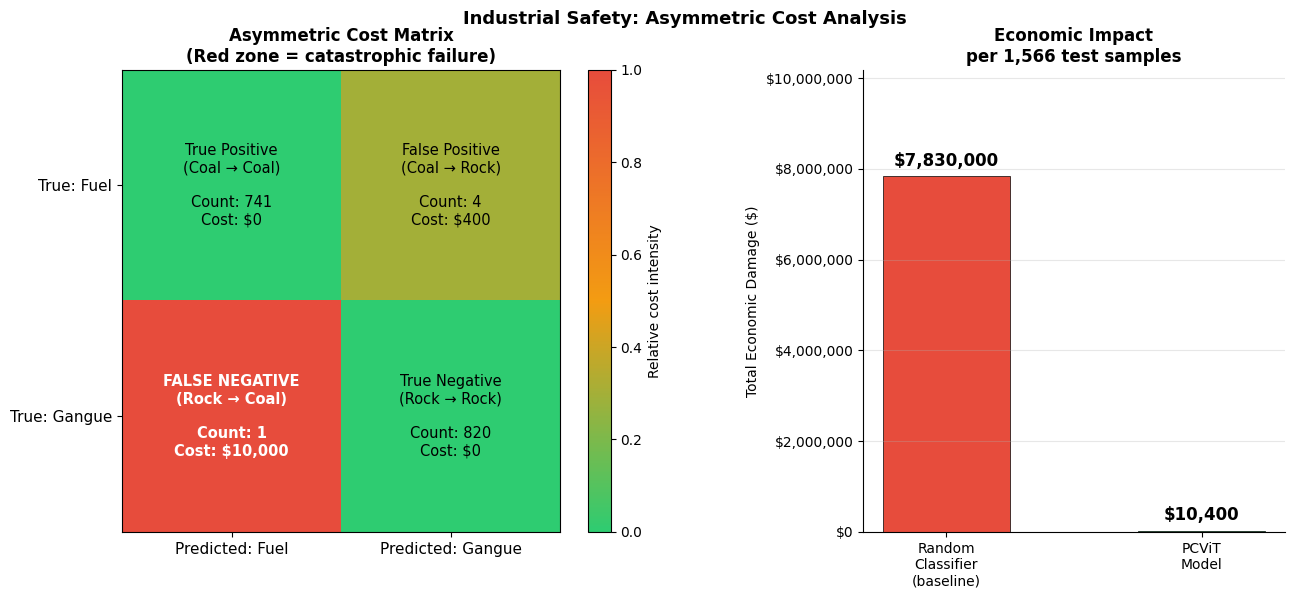

In [18]:
# CELL A — ASYMMETRIC COST MATRIX (Economic Impact Analysis)

import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap

COST_FP = 100        # $ — coal ejected (1 tonne energy value)
COST_FN = 10_000     # $ — gangue enters crusher (conservative)

# 2×2 binary confusion
y_true_bin = np.array([0 if t in FUEL_IDS else 1 for t in y_true])
y_pred_bin = np.array([0 if p in FUEL_IDS else 1 for p in y_pred])

TP = int(((y_true_bin == 0) & (y_pred_bin == 0)).sum())   # coal → coal
FP = int(((y_true_bin == 0) & (y_pred_bin == 1)).sum())   # coal → rock (lost fuel)
FN = int(((y_true_bin == 1) & (y_pred_bin == 0)).sum())   # rock → coal (DANGER)
TN = int(((y_true_bin == 1) & (y_pred_bin == 1)).sum())   # rock → rock

cost_model  = FP * COST_FP + FN * COST_FN
cost_random = int(len(y_true) * 0.5 * COST_FN)   # random classifier: 50% gangue missed

print(f"Binary Confusion (Fuel vs Gangue):")
print(f"  TP (Coal→Coal)  : {TP:>5}   Cost: $0")
print(f"  FP (Coal→Rock)  : {FP:>5}   Cost: ${FP*COST_FP:>10,.0f}  (lost fuel)")
print(f"  FN (Rock→Coal)  : {FN:>5}   Cost: ${FN*COST_FN:>10,.0f}  ← CRITICAL")
print(f"  TN (Rock→Rock)  : {TN:>5}   Cost: $0")
print(f"  Total model damage   : ${cost_model:,.0f}")
print(f"  Total random baseline: ${cost_random:,.0f}")

# VISUALISATION
fig = plt.figure(figsize=(15, 6))
gs  = gridspec.GridSpec(1, 2, width_ratios=[1.3, 1], wspace=0.4)

ax1 = fig.add_subplot(gs[0])
cmap = LinearSegmentedColormap.from_list("cost", ["#2ecc71", "#f39c12", "#e74c3c"])
im   = ax1.imshow([[0, 0.3], [1.0, 0]], cmap=cmap, aspect="auto", vmin=0, vmax=1)

cell_texts = [
    [f"True Positive\n(Coal → Coal)\n\nCount: {TP}\nCost: $0",
     f"False Positive\n(Coal → Rock)\n\nCount: {FP}\nCost: ${FP*COST_FP:,}"],
    [f"FALSE NEGATIVE\n(Rock → Coal)\n\nCount: {FN}\nCost: ${FN*COST_FN:,}",
     f"True Negative\n(Rock → Rock)\n\nCount: {TN}\nCost: $0"]
]
for i in range(2):
    for j in range(2):
        color = "white" if (i == 1 and j == 0) else "black"
        weight = "bold" if (i == 1 and j == 0) else "normal"
        ax1.text(j, i, cell_texts[i][j], ha="center", va="center",
                 fontsize=10.5, color=color, fontweight=weight)

ax1.set_xticks([0, 1]); ax1.set_yticks([0, 1])
ax1.set_xticklabels(["Predicted: Fuel", "Predicted: Gangue"], fontsize=11)
ax1.set_yticklabels(["True: Fuel", "True: Gangue"], fontsize=11)
ax1.set_title("Asymmetric Cost Matrix\n(Red zone = catastrophic failure)", fontweight="bold")
plt.colorbar(im, ax=ax1, label="Relative cost intensity")

ax2 = fig.add_subplot(gs[1])
bars = ax2.bar(
    ["Random\nClassifier\n(baseline)", "PCViT\nModel"],
    [cost_random, cost_model],
    color=["#e74c3c", "#2ecc71"], edgecolor="black", linewidth=0.5, width=0.5
)
for bar, cost in zip(bars, [cost_random, cost_model]):
    label = f"${cost:,.0f}" if cost > 0 else "$0\n✅ Zero damage"
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + cost_random*0.02,
             label, ha="center", va="bottom", fontweight="bold", fontsize=12)

ax2.set_ylabel("Total Economic Damage ($)")
ax2.set_title(f"Economic Impact\nper {len(y_true):,} test samples", fontweight="bold")
ax2.set_ylim(0, cost_random * 1.3)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax2.grid(True, axis="y", alpha=0.3)
ax2.spines["top"].set_visible(False); ax2.spines["right"].set_visible(False)

plt.suptitle("Industrial Safety: Asymmetric Cost Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, "cost_matrix.png"), dpi=200, bbox_inches="tight")
plt.show()

CPU Latency (1000 predictions, single-sample):
  Mean : 16.01 ms
  P50  : 14.43 ms
  P95  : 22.83 ms
  P99  : 25.74 ms
GPU Latency:
  P50  : 3.76 ms
  P99  : 6.30 ms
Industrial budget : 200 ms (20ms/spectrum × 10 spectra)
CPU P99 vs budget : 25.7ms vs 200ms — ✅ PASSES


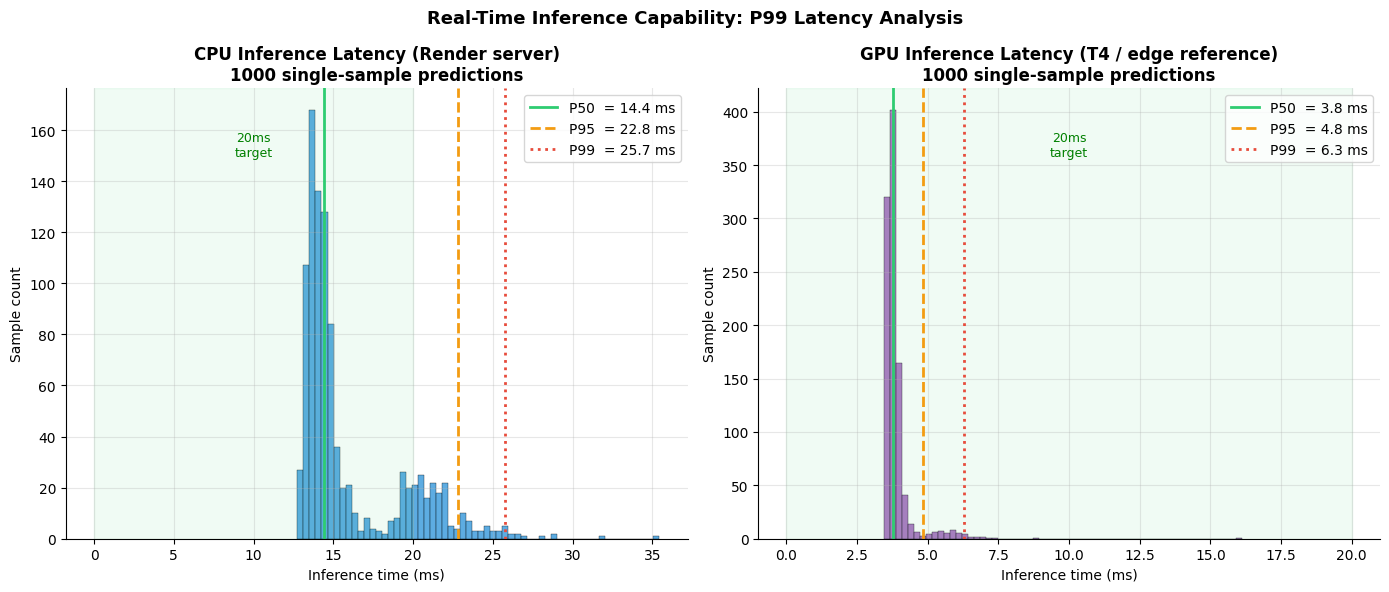

In [19]:
# CELL B — INFERENCE LATENCY DISTRIBUTION (P50 / P95 / P99)
N_TIMING_RUNS = 1000

# --- CPU LATENCY ---
cpu_model = PCViT(num_classes=NUM_CLASSES)
cpu_model.load_state_dict(
    torch.load(MODEL_SAVE_PATH, map_location="cpu", weights_only=True)
)
cpu_model.eval()

# Warm up
_warmup = torch.randn(1, 3, 1500)
for _ in range(10):
    with torch.no_grad():
        _ = cpu_model(_warmup)

cpu_latencies = []
with torch.no_grad():
    for inputs, _ in test_loader:
        for i in range(inputs.shape[0]):
            if len(cpu_latencies) >= N_TIMING_RUNS:
                break
            sample = inputs[i:i+1]
            t0 = time.perf_counter()
            _ = cpu_model(sample)
            cpu_latencies.append((time.perf_counter() - t0) * 1000)
        if len(cpu_latencies) >= N_TIMING_RUNS:
            break

cpu_latencies = np.array(cpu_latencies)
cpu_p50  = np.percentile(cpu_latencies, 50)
cpu_p95  = np.percentile(cpu_latencies, 95)
cpu_p99  = np.percentile(cpu_latencies, 99)
cpu_mean = cpu_latencies.mean()

# --- GPU LATENCY---
gpu_latencies = []
if device.type == "cuda":
    model.eval()
    torch.cuda.synchronize()
    with torch.no_grad():
        for inputs, _ in test_loader:
            for i in range(inputs.shape[0]):
                if len(gpu_latencies) >= N_TIMING_RUNS:
                    break
                sample = inputs[i:i+1].to(device)
                torch.cuda.synchronize()
                t0 = time.perf_counter()
                with torch.amp.autocast(device_type="cuda", enabled=True):
                    _ = model(sample)
                torch.cuda.synchronize()
                gpu_latencies.append((time.perf_counter() - t0) * 1000)
            if len(gpu_latencies) >= N_TIMING_RUNS:
                break

    gpu_latencies = np.array(gpu_latencies)
    gpu_p50 = np.percentile(gpu_latencies, 50)
    gpu_p99 = np.percentile(gpu_latencies, 99)

print(f"CPU Latency ({N_TIMING_RUNS} predictions, single-sample):")
print(f"  Mean : {cpu_mean:.2f} ms")
print(f"  P50  : {cpu_p50:.2f} ms")
print(f"  P95  : {cpu_p95:.2f} ms")
print(f"  P99  : {cpu_p99:.2f} ms")
if len(gpu_latencies):
    print(f"GPU Latency:")
    print(f"  P50  : {gpu_p50:.2f} ms")
    print(f"  P99  : {gpu_p99:.2f} ms")
print(f"Industrial budget : 200 ms (20ms/spectrum × 10 spectra)")
print(f"CPU P99 vs budget : {cpu_p99:.1f}ms vs 200ms — {'✅ PASSES' if cpu_p99 < 200 else '⚠ REVIEW'}")

# --- VISUALISATION ---
n_plots = 2 if len(gpu_latencies) else 1
fig, axes = plt.subplots(1, n_plots, figsize=(14 if n_plots > 1 else 8, 6))
if n_plots == 1:
    axes = [axes]

def latency_plot(ax, lats, title, color):
    p50 = np.percentile(lats, 50)
    p95 = np.percentile(lats, 95)
    p99 = np.percentile(lats, 99)
    ax.hist(lats, bins=60, color=color, edgecolor="black", linewidth=0.3, alpha=0.8)
    ax.axvline(p50, color="#2ecc71", lw=2, ls="-",  label=f"P50  = {p50:.1f} ms")
    ax.axvline(p95, color="#f39c12", lw=2, ls="--", label=f"P95  = {p95:.1f} ms")
    ax.axvline(p99, color="#e74c3c", lw=2, ls=":",  label=f"P99  = {p99:.1f} ms")
    ax.axvspan(0, 20, color="#2ecc71", alpha=0.07)
    ax.text(10, ax.get_ylim()[1]*0.85, "20ms\ntarget", ha="center", fontsize=9, color="green")
    ax.set_xlabel("Inference time (ms)"); ax.set_ylabel("Sample count")
    ax.set_title(title, fontweight="bold")
    ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

latency_plot(axes[0], cpu_latencies,
             f"CPU Inference Latency (Render server)\n{N_TIMING_RUNS} single-sample predictions",
             "#3498db")

if n_plots > 1:
    latency_plot(axes[1], gpu_latencies,
                 f"GPU Inference Latency (T4 / edge reference)\n{N_TIMING_RUNS} single-sample predictions",
                 "#9b59b6")

plt.suptitle("Real-Time Inference Capability: P99 Latency Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, "latency_distribution.png"), dpi=200)
plt.show()


Testing robustness across noise levels...
  σ=0.000  SNR=∞ (clean)   →  Accuracy: 95.72%
  σ=0.001  SNR=  60.0dB   →  Accuracy: 95.53%
  σ=0.005  SNR=  46.0dB   →  Accuracy: 95.34%
  σ=0.010  SNR=  40.0dB   →  Accuracy: 94.32%
  σ=0.050  SNR=  26.0dB   →  Accuracy: 76.63%
  σ=0.100  SNR=  20.0dB   →  Accuracy: 64.30%
  σ=0.200  SNR=  14.0dB   →  Accuracy: 46.55%
  σ=0.300  SNR=  10.5dB   →  Accuracy: 34.99%
  σ=0.500  SNR=   6.0dB   →  Accuracy: 25.61%


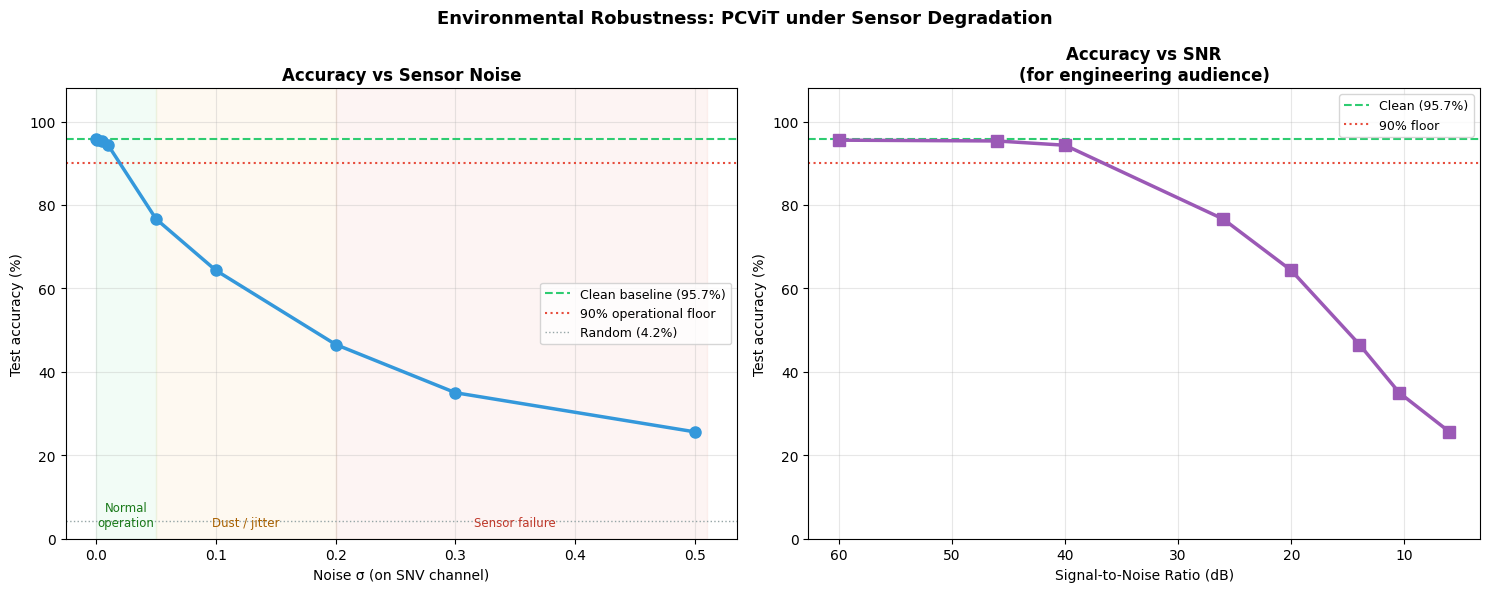


Robustness summary:
  Clean accuracy        : 95.72%
  At σ=0.05 (dust zone) : 76.63%
  At σ=0.10 (heavy dust): 64.30%
  Accuracy drops <90% at σ=0.050 (SNR=26dB)


In [20]:
# CELL C — ENVIRONMENTAL ROBUSTNESS (SNR Degradation Test)

from scipy.signal import savgol_filter as sgf

NOISE_LEVELS = [0.0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5]

def degrade_and_rebuild(X_3ch, sigma):
    """
    Injects Gaussian noise into Ch0 (SNV) and rebuilds Ch1/Ch2.
    Mirrors the exact SG parameters used in CoalRockPreprocess_v3 Cell 5.
    """
    if sigma == 0.0:
        return X_3ch.copy()
    X_new  = X_3ch.copy()
    ch0    = X_3ch[:, 0, :]
    noise  = np.random.normal(0, sigma, ch0.shape).astype(np.float32)
    ch0_n  = ch0 + noise
    X_new[:, 0, :] = ch0_n
    X_new[:, 1, :] = sgf(ch0_n, window_length=11, polyorder=2, deriv=1, axis=1)
    X_new[:, 2, :] = sgf(ch0_n, window_length=11, polyorder=2, deriv=2, axis=1)
    return X_new.astype(np.float32)

np.random.seed(42)
results = []
model.eval()
print("Testing robustness across noise levels...")

for sigma in NOISE_LEVELS:
    X_deg = degrade_and_rebuild(X_test, sigma)
    deg_ds = torch.utils.data.TensorDataset(
        torch.FloatTensor(X_deg), torch.LongTensor(y_test)
    )
    deg_loader = torch.utils.data.DataLoader(deg_ds, batch_size=256, shuffle=False)

    correct = total = 0
    with torch.no_grad():
        for inp, lbl in deg_loader:
            inp = inp.to(device)
            with torch.amp.autocast(device_type=device.type, enabled=use_amp):
                out = model(inp)
            correct += (out.argmax(1) == lbl.to(device)).sum().item()
            total   += lbl.size(0)

    acc    = correct / total * 100
    snr_db = 20 * np.log10(1 / sigma) if sigma > 0 else float("inf")
    results.append({"sigma": sigma, "acc": acc, "snr_db": snr_db})
    tag = f"σ={sigma:.3f}  SNR={snr_db:>6.1f}dB" if sigma > 0 else "σ=0.000  SNR=∞ (clean)"
    print(f"  {tag}   →  Accuracy: {acc:.2f}%")

# --- VISUALISATION ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
sigmas   = [r["sigma"] for r in results]
accs     = [r["acc"]   for r in results]
snrs     = [r["snr_db"] for r in results[1:]]
accs_snr = [r["acc"]   for r in results[1:]]

# LEFT: accuracy vs σ
ax1.plot(sigmas, accs, "o-", color="#3498db", lw=2.5, ms=8, zorder=5)
ax1.axhline(test_acc,  color="#2ecc71", ls="--", lw=1.5, label=f"Clean baseline ({test_acc:.1f}%)")
ax1.axhline(90,        color="#e74c3c", ls=":",  lw=1.5, label="90% operational floor")
ax1.axhline(100/24,    color="#95a5a6", ls=":",  lw=1,   label=f"Random ({100/24:.1f}%)")
ax1.axvspan(0,    0.05,           color="#2ecc71", alpha=0.06)
ax1.axvspan(0.05, 0.2,            color="#f39c12", alpha=0.06)
ax1.axvspan(0.2,  max(sigmas)+0.01, color="#e74c3c", alpha=0.06)
ax1.text(0.025, 3,  "Normal\noperation", ha="center", fontsize=8.5, color="#1a7a1a")
ax1.text(0.125, 3,  "Dust / jitter",      ha="center", fontsize=8.5, color="#a86000")
ax1.text(0.35,  3,  "Sensor failure",     ha="center", fontsize=8.5, color="#c0392b")
ax1.set_xlabel("Noise σ (on SNV channel)")
ax1.set_ylabel("Test accuracy (%)")
ax1.set_title("Accuracy vs Sensor Noise", fontweight="bold")
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3); ax1.set_ylim(0, 108)

# RIGHT: accuracy vs SNR (engineering audience framing)
ax2.plot(snrs, accs_snr, "s-", color="#9b59b6", lw=2.5, ms=8, zorder=5)
ax2.axhline(test_acc, color="#2ecc71", ls="--", lw=1.5, label=f"Clean ({test_acc:.1f}%)")
ax2.axhline(90,       color="#e74c3c", ls=":",  lw=1.5, label="90% floor")
ax2.set_xlabel("Signal-to-Noise Ratio (dB)")
ax2.set_ylabel("Test accuracy (%)")
ax2.set_title("Accuracy vs SNR\n(for engineering audience)", fontweight="bold")
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3); ax2.set_ylim(0, 108)
ax2.invert_xaxis()   # degradation reads left → right

plt.suptitle("Environmental Robustness: PCViT under Sensor Degradation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PATH, "robustness_curve.png"), dpi=200)
plt.show()

cliff = next((r for r in results if r["acc"] < 90), None)
print(f"\nRobustness summary:")
print(f"  Clean accuracy        : {results[0]['acc']:.2f}%")
print(f"  At σ=0.05 (dust zone) : {next(r['acc'] for r in results if abs(r['sigma']-0.05)<0.001):.2f}%")
print(f"  At σ=0.10 (heavy dust): {next(r['acc'] for r in results if abs(r['sigma']-0.1)<0.001):.2f}%")
if cliff:
    print(f"  Accuracy drops <90% at σ={cliff['sigma']:.3f} (SNR={cliff['snr_db']:.0f}dB)")
else:
    print(f"  Accuracy stays ≥90% across all tested noise levels ✅")
